# T1 — EDA
**Dataset:** ~51,490 trận Liên Minh Huyền Thoại — Season 9 (ranked)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter
from pathlib import Path

ROOT = Path('../../')
RAW  = ROOT / 'data' / 'raw'

df = pd.read_csv(RAW / 'games.csv')

with open(RAW / 'champion_info.json',       encoding='utf-8') as f: champ_info  = json.load(f)['data']
with open(RAW / 'champion_info_2.json',     encoding='utf-8') as f: champ_info2 = json.load(f)['data']
with open(RAW / 'summoner_spell_info.json', encoding='utf-8') as f: spell_info  = json.load(f)['data']

# Lookups
id_to_name       = {info['id']: info['name']             for info in champ_info.values()}
id_to_tags       = {info['id']: info.get('tags', [])     for info in champ_info2.values()}
spell_id_to_name = {int(k): v['name']                    for k, v in spell_info.items()}

# Column groups
pick_cols  = [c for c in df.columns if 'champ' in c and 'sum' not in c and 'ban' not in c]
spell_cols = [c for c in df.columns if '_sum' in c]
ban_cols   = [c for c in df.columns if 'ban' in c]
t1_picks   = [f't1_champ{i}id' for i in range(1, 6)]
t2_picks   = [f't2_champ{i}id' for i in range(1, 6)]

# Global style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.0)
plt.rcParams['figure.dpi'] = 110
C1, C2 = '#4C82C2', '#E07B54'

## 1. Tổng quan Dataset

In [2]:
df.describe().T[['count','mean','std','min','50%','max']]

,count,mean,std,min,50%,max
gameId,51490.0,3.306223e+09,2.946096e+07,3.214824e+09,3.320021e+09,3.331833e+09
creationTime,51490.0,1.502926e+12,1.978026e+09,1.496892e+12,1.503844e+12,1.504707e+12
gameDuration,51490.0,1.832363e+03,5.120177e+02,1.900000e+02,1.833000e+03,4.728000e+03
seasonId,51490.0,9.000000e+00,0.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00
winner,51490.0,1.493552e+00,4.999633e-01,1.000000e+00,1.000000e+00,2.000000e+00
...,...,...,...,...,...,...
t2_ban1,51490.0,1.082163e+02,1.025518e+02,-1.000000e+00,9.000000e+01,5.160000e+02
t2_ban2,51490.0,1.079102e+02,1.028707e+02,-1.000000e+00,9.000000e+01,5.160000e+02
t2_ban3,51490.0,1.086906e+02,1.025921e+02,-1.000000e+00,9.000000e+01,5.160000e+02
t2_ban4,51490.0,1.086260e+02,1.033470e+02,-1.000000e+00,9.000000e+01,5.160000e+02


## 2. Biến Target: `winner`

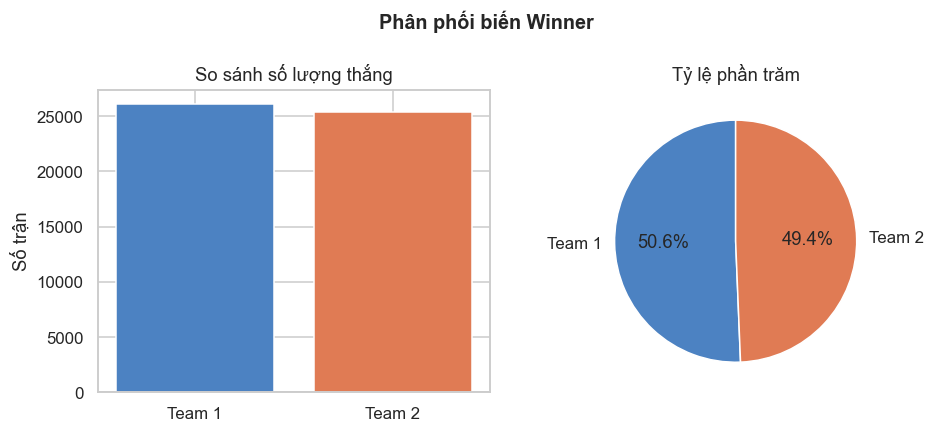

In [3]:
vc = df['winner'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].bar(['Team 1', 'Team 2'], [vc[1], vc[2]], color=[C1, C2])
axes[0].set_title('So sánh số lượng thắng')
axes[0].set_ylabel('Số trận')

axes[1].pie([vc[1], vc[2]], labels=['Team 1', 'Team 2'],
            colors=[C1, C2], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Tỷ lệ phần trăm')

plt.suptitle('Phân phối biến Winner', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Thời gian trận đấu

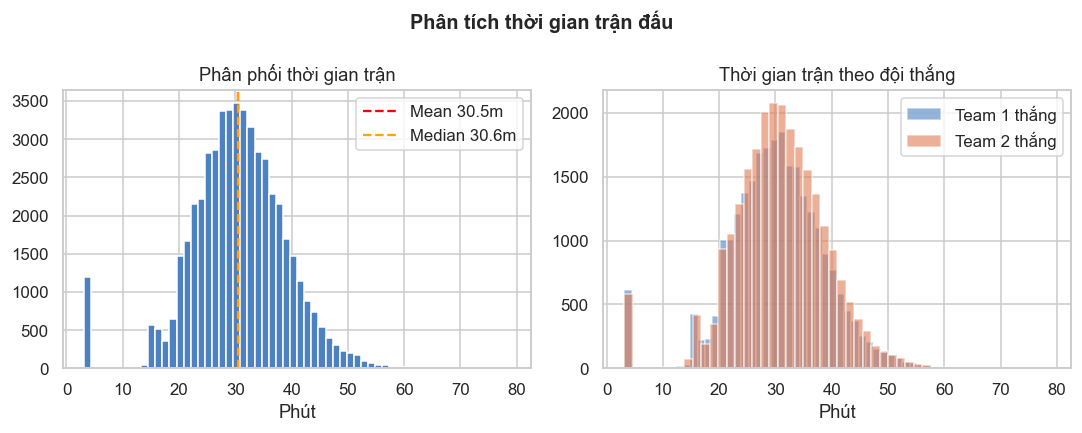

In [4]:
dur = df['gameDuration'] / 60

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(dur, bins=60, color=C1)
axes[0].axvline(dur.mean(),   color='red',    linestyle='--', label=f'Mean {dur.mean():.1f}m')
axes[0].axvline(dur.median(), color='orange', linestyle='--', label=f'Median {dur.median():.1f}m')
axes[0].set_xlabel('Phút')
axes[0].set_title('Phân phối thời gian trận')
axes[0].legend()

axes[1].hist(dur[df['winner'] == 1], bins=50, alpha=0.6, color=C1, label='Team 1 thắng')
axes[1].hist(dur[df['winner'] == 2], bins=50, alpha=0.6, color=C2, label='Team 2 thắng')
axes[1].set_xlabel('Phút')
axes[1].set_title('Thời gian trận theo đội thắng')
axes[1].legend()

plt.suptitle('Phân tích thời gian trận đấu', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

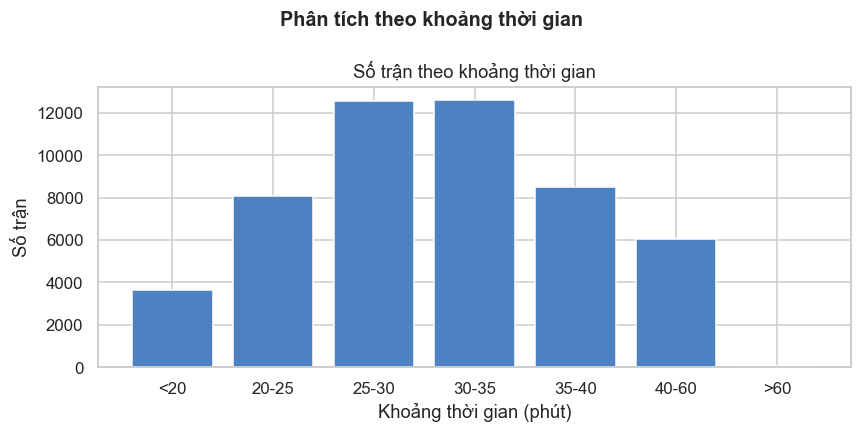

In [5]:
bins   = [0, 20, 25, 30, 35, 40, 60, 999]
labels = ['<20', '20-25', '25-30', '30-35', '35-40', '40-60', '>60']
df['dur_bucket'] = pd.cut(dur, bins=bins, labels=labels)

bucket = df.groupby('dur_bucket', observed=True).agg(
    so_tran=('winner', 'size')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(bucket['dur_bucket'], bucket['so_tran'], color=C1)
ax.set_xlabel('Khoảng thời gian (phút)')
ax.set_ylabel('Số trận')
ax.set_title('Số trận theo khoảng thời gian')
plt.suptitle('Phân tích theo khoảng thời gian', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

df.drop(columns=['dur_bucket'], inplace=True)

## 4. Ma trận tương quan First Objectives (tham khảo — không dùng trong T1)

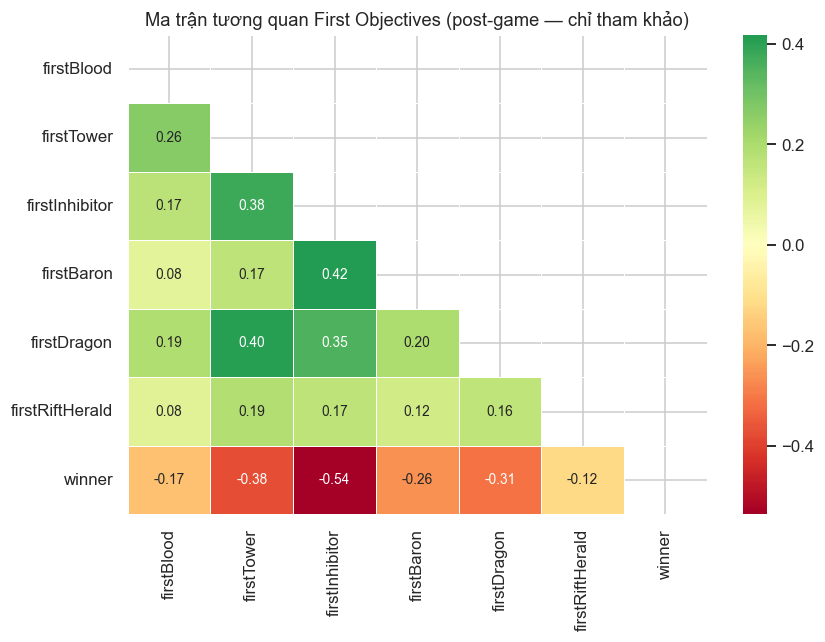

In [190]:
first_cols    = ['firstBlood', 'firstTower', 'firstInhibitor', 'firstBaron', 'firstDragon', 'firstRiftHerald']
winner_bin_tmp = (df['winner'] == 1).astype(int)

corr_first = df[first_cols].assign(winner=winner_bin_tmp).corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_first, dtype=bool))
sns.heatmap(corr_first, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Ma trận tương quan First Objectives (post-game — chỉ tham khảo)', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Champion Picks

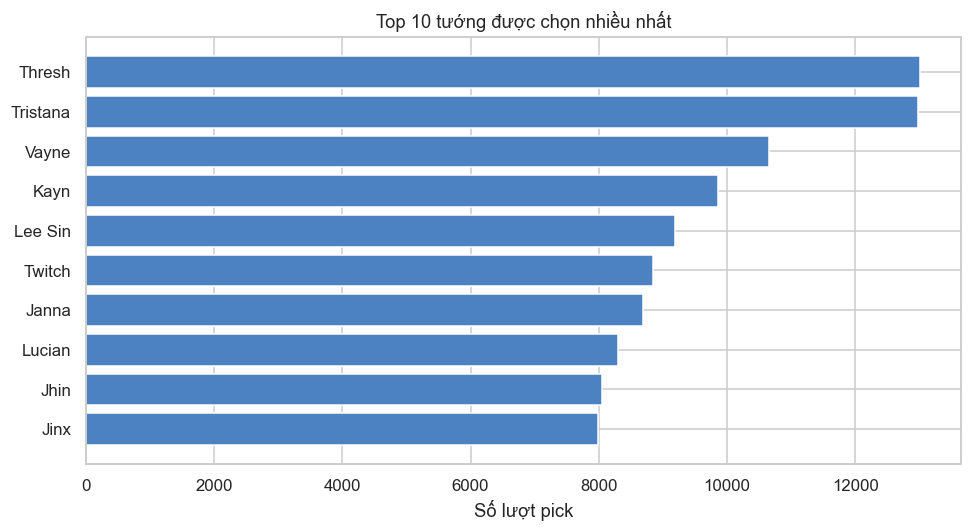

In [191]:
pick_counter = Counter()
for col in pick_cols:
    pick_counter.update(df[col].tolist())

top10_picks = pd.DataFrame(pick_counter.most_common(10), columns=['id', 'count'])
top10_picks['name'] = top10_picks['id'].map(id_to_name)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10_picks['name'][::-1], top10_picks['count'][::-1], color=C1)
ax.set_xlabel('Số lượt pick')
ax.set_title('Top 10 tướng được chọn nhiều nhất')
plt.tight_layout()
plt.show()

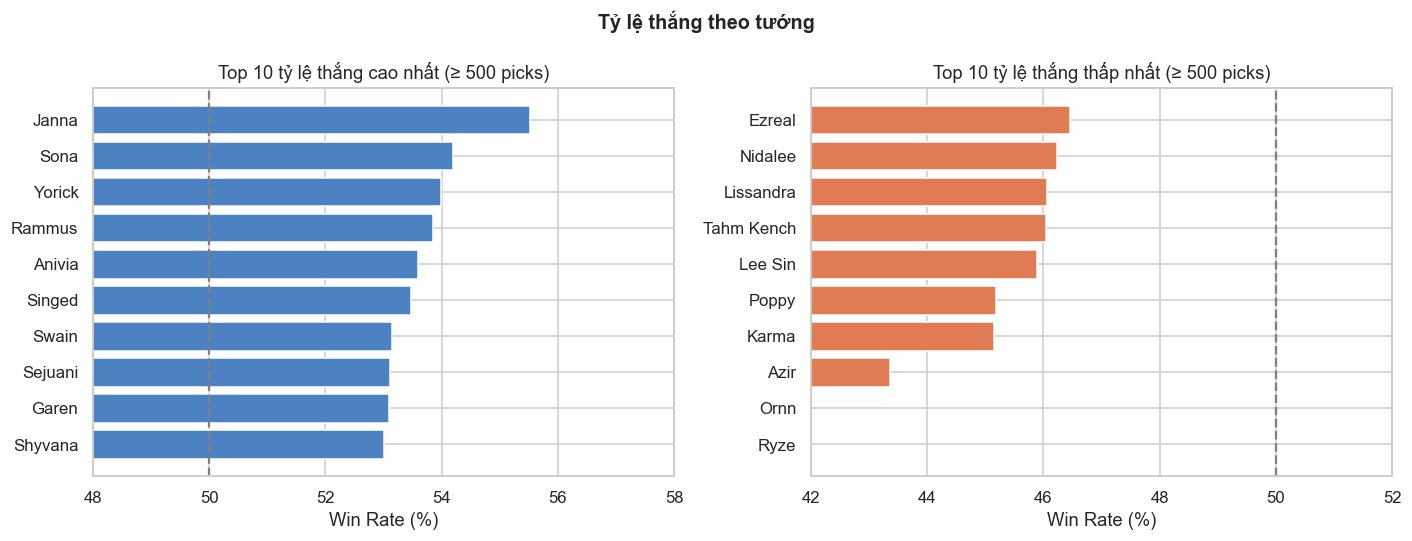

In [192]:
records = []
for col in pick_cols:
    team = 1 if col.startswith('t1') else 2
    tmp = df[[col, 'winner']].copy()
    tmp.columns = ['champ_id', 'winner']
    tmp['won'] = (tmp['winner'] == team).astype(int)
    records.append(tmp[['champ_id', 'won']])

wr_df = pd.concat(records, ignore_index=True)
champ_wr = (wr_df.groupby('champ_id')
               .agg(picks=('won', 'size'), wr=('won', 'mean'))
               .reset_index())
champ_wr['wr'] *= 100
champ_wr['name'] = champ_wr['champ_id'].map(id_to_name)
champ_wr = champ_wr[champ_wr['picks'] >= 500]

top10_wr = champ_wr.nlargest(10, 'wr')
bot10_wr = champ_wr.nsmallest(10, 'wr')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(top10_wr['name'][::-1], top10_wr['wr'][::-1], color=C1)
axes[0].axvline(50, color='gray', linestyle='--')
axes[0].set_xlabel('Win Rate (%)')
axes[0].set_title('Top 10 tỷ lệ thắng cao nhất (≥ 500 picks)')
axes[0].set_xlim(48, 58)

axes[1].barh(bot10_wr['name'], bot10_wr['wr'], color=C2)
axes[1].axvline(50, color='gray', linestyle='--')
axes[1].set_xlabel('Win Rate (%)')
axes[1].set_title('Top 10 tỷ lệ thắng thấp nhất (≥ 500 picks)')
axes[1].set_xlim(42, 52)

plt.suptitle('Tỷ lệ thắng theo tướng', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Champion Bans

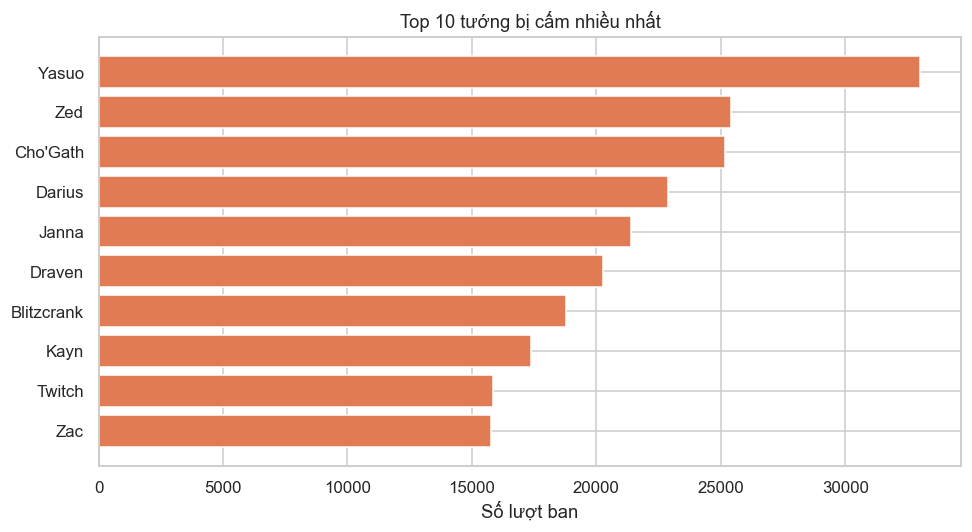

In [193]:
ban_counter = Counter()
for col in ban_cols:
    ban_counter.update(df[col].tolist())
for k in [-1, 0]: ban_counter.pop(k, None)

top10_bans = pd.DataFrame(ban_counter.most_common(10), columns=['id', 'count'])
top10_bans['name'] = top10_bans['id'].map(id_to_name)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10_bans['name'][::-1], top10_bans['count'][::-1], color=C2)
ax.set_xlabel('Số lượt ban')
ax.set_title('Top 10 tướng bị cấm nhiều nhất')
plt.tight_layout()
plt.show()

## 7. Summoner Spells

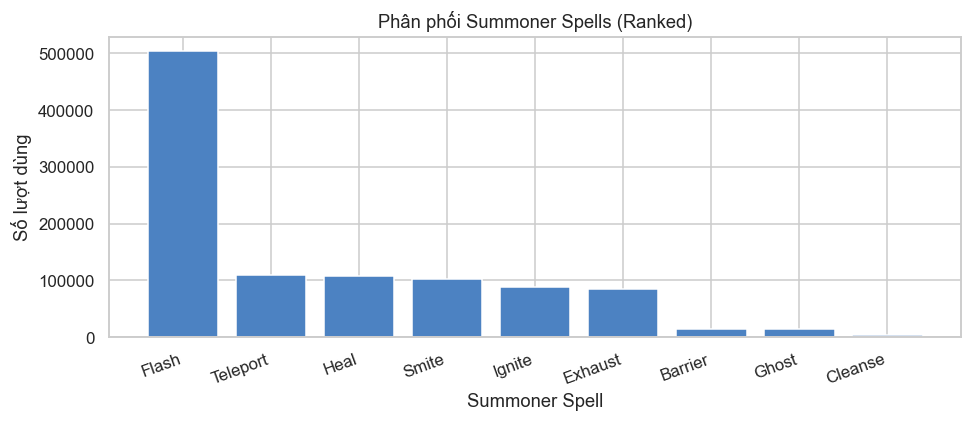

In [194]:
spell_counter = Counter()
for col in spell_cols:
    spell_counter.update(df[col].tolist())

ranked_ids = {1, 3, 4, 6, 7, 11, 12, 14, 21}
spell_data = pd.DataFrame(
    [(spell_id_to_name.get(sid, f'ID {sid}'), cnt)
     for sid, cnt in spell_counter.most_common() if sid in ranked_ids],
    columns=['name', 'count']
).sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(spell_data['name'], spell_data['count'], color=C1)
ax.set_xlabel('Summoner Spell')
ax.set_ylabel('Số lượt dùng')
ax.set_title('Phân phối Summoner Spells (Ranked)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 8. Phân tích vai trò tướng (champion_info_2.json)

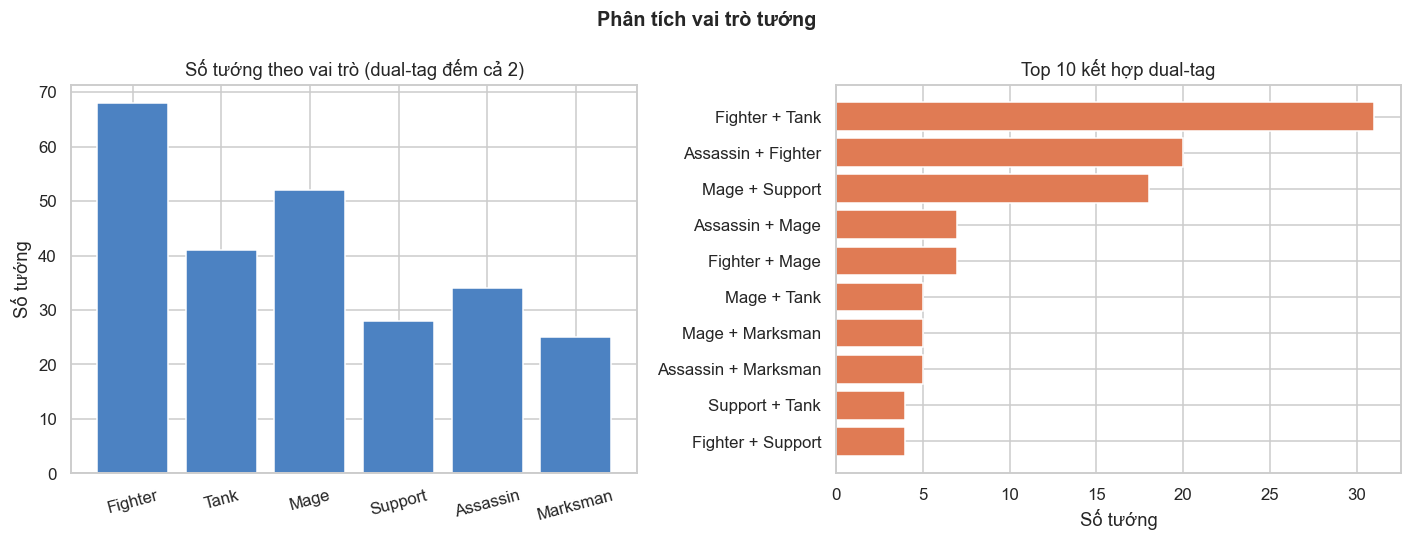

In [195]:
ALL_TAGS = ['Fighter', 'Tank', 'Mage', 'Support', 'Assassin', 'Marksman']

tag_counter   = Counter(t for tags in id_to_tags.values() for t in tags)
combo_counter = Counter(
    ' + '.join(sorted(tags))
    for tags in id_to_tags.values() if len(tags) == 2
)

top10_combos = pd.DataFrame(combo_counter.most_common(10), columns=['combo', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(ALL_TAGS, [tag_counter[t] for t in ALL_TAGS], color=C1)
axes[0].set_ylabel('Số tướng')
axes[0].set_title('Số tướng theo vai trò (dual-tag đếm cả 2)')
plt.setp(axes[0].get_xticklabels(), rotation=15)

axes[1].barh(top10_combos['combo'][::-1], top10_combos['count'][::-1], color=C2)
axes[1].set_xlabel('Số tướng')
axes[1].set_title('Top 10 kết hợp dual-tag')

plt.suptitle('Phân tích vai trò tướng', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

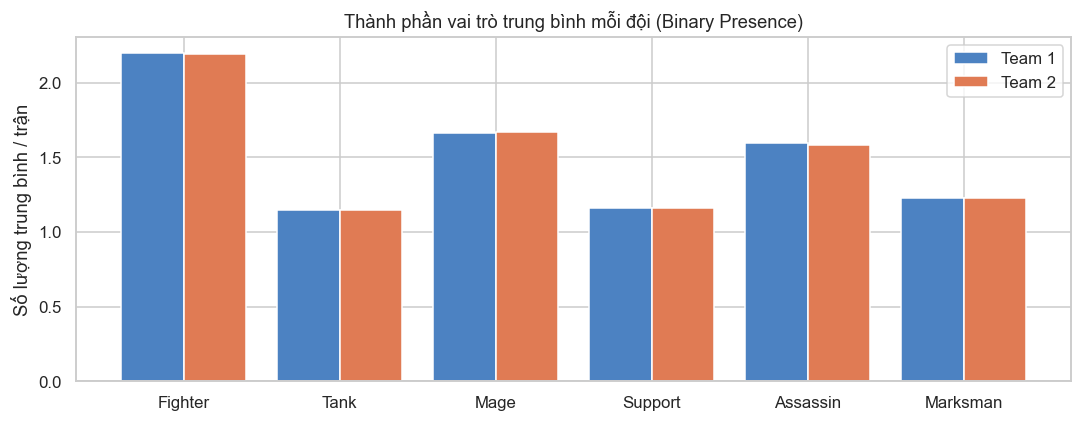

In [196]:
def team_role_counts(df, picks, id_to_tags, tags):
    result = {}
    for tag in tags:
        counts = sum(
            df[col].map(lambda cid: tag in id_to_tags.get(cid, []))
            for col in picks
        )
        result[tag] = counts.values
    return pd.DataFrame(result)

t1_roles = team_role_counts(df, t1_picks, id_to_tags, ALL_TAGS)
t2_roles = team_role_counts(df, t2_picks, id_to_tags, ALL_TAGS)

mean_t1 = t1_roles.mean()
mean_t2 = t2_roles.mean()

x = np.arange(len(ALL_TAGS))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.2, mean_t1, 0.4, label='Team 1', color=C1)
ax.bar(x + 0.2, mean_t2, 0.4, label='Team 2', color=C2)
ax.set_xticks(x)
ax.set_xticklabels(ALL_TAGS)
ax.set_ylabel('Số lượng trung bình / trận')
ax.set_title('Thành phần vai trò trung bình mỗi đội (Binary Presence)')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Tổng kết

| Hạng mục | Kết quả |
|---|---|
| Dataset | 51,490 trận, 61 cột, 0 null, Season 9 |
| Class balance | Team1 50.7% / Team2 49.3% — cân bằng |
| Thời gian trận | Mean 30.5 phút, trận <5p: ~1195 (cần lọc bỏ) |
| Champion coverage | 100% ID trong JSON |
| Dual-tag champions | 110/138 tướng có 2 tags — dùng Binary Presence |
| In-game correlation | Rất cao (tower/baron kills ~0.7–0.9) |
| Pre-game correlation | Rất thấp (<0.05) — accuracy dự kiến 60–68% |

**Quyết định cho `t1_preprocess.py`:**
- Drop toàn bộ in-game stats + gameDuration
- Lọc trận < 300 giây
- Tính 12 cột role_count (Binary Presence) + 6 cột diff_role
- Convert winner: 1→0, 2→1
- Train-test split 80/20 stratified